### In this notebook we put the Greedy ANN to test, by using it on a data set of clusters. 

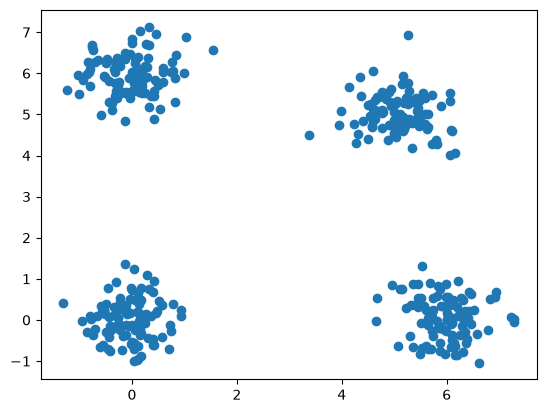

In [17]:
'''
Only this part of the code is different from lecture 1, rest everything is same. 
'''

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cluster1 = np.random.randn(100, 2) * 0.5 + np.array([0, 0])
cluster2 = np.random.randn(100, 2) * 0.5 + np.array([5, 5])
cluster3 = np.random.randn(100, 2) * 0.5 + np.array([0, 6])
cluster4 = np.random.randn(100, 2) * 0.5 + np.array([6, 0])

X = np.vstack([
    cluster1,
    cluster2,
    cluster3,
    cluster4
])

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [2]:
def euclid(x, y): 
    # x and y both are vectors here
    return np.linalg.norm(x-y)

In [3]:
def get_knn(X, i, k):
    '''
    X : data matrix containing vectors 
    i : the index of the vector whose K nearest neighbours we search 
    k : hyperparameter
    '''
    distances = []

    for j in range(len(X)):
        if i == j:
            continue

        d = euclid(X[i], X[j])
        distances.append((d, j))

    distances.sort()

    return [j for _, j in distances[:k]]

In [4]:
def build_knn_graph(X, k): 
    graph = {}
    
    for i in range(len(X)): 
        graph[i] = get_knn(X, i, k)
    
    return graph 

In [5]:
g = build_knn_graph(X,8)

In [9]:
# Visualizing the graph 
def plot_graph(X, graph):
    plt.figure(figsize=(10, 10))

    # Draw points
    plt.scatter(X[:, 0], X[:, 1])

    # Draw edges
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.2
            )

    plt.show()

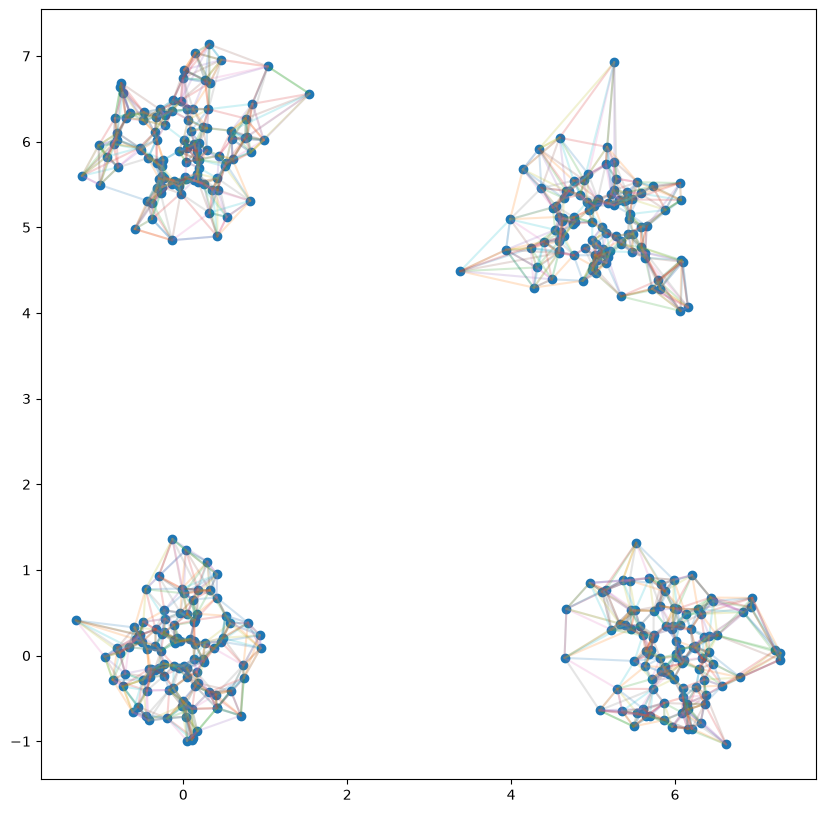

In [10]:
plot_graph(X, g)

In [11]:
def greedy_search(X, graph, query, start): 
    current = start 
    path = [current]
    # steps = 0 
    
    while True: 
        # # just a safety check 
        # if steps > 100: 
        #     break 
        
        neighbours = graph[current]
        current_dist = euclid(X[current], query)
        best_choice = []
        
        for n in neighbours: 
            d = euclid(query, X[n])
            if d  < current_dist: 
                best_choice.append((n, d)) 
        
        if best_choice == []: 
            # local minium 
            break
        else: 
            best_choice.sort(key=lambda t : t[1])
            current = best_choice[0][0]
            path.append(current)
        
        # steps += 1   
    
    return current, path

In [12]:
query = np.array([1.5, 1.5])

result, path = greedy_search(
    X,
    g,
    query,
    start=0
)

print("Graph result:", result)
print("Point:", X[result])

Graph result: 3
Point: [0.78960641 0.38371736]


In [13]:
path

[0, 20, 82, 3]

In [14]:
def exact_search(X, query):
    distances = np.linalg.norm(X - query, axis=1)
    return np.argmin(distances)

print(exact_search(X, query))

83


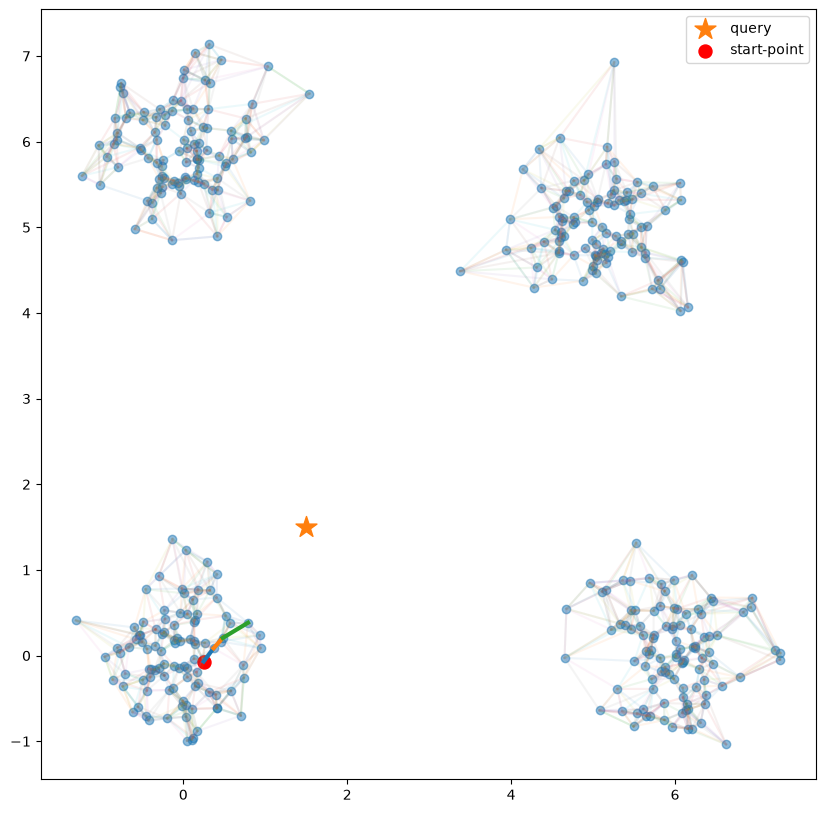

In [15]:
def plot_search(X, graph, query, path):

    plt.figure(figsize=(10, 10))

    # Graph
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.08
            )

    # All points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        alpha=0.5
    )

    # Query
    plt.scatter(
        query[0],
        query[1],
        marker="*",
        s=250, 
        label = 'query'
    )

    plt.scatter(
        X[path[0]][0],
        X[path[0]][1], 
        marker = '.', 
        s = 350, 
        c = 'r', 
        label='start-point'
    )
    
    # Search path
    for a, b in zip(path[:-1], path[1:]):
        plt.plot(
            [X[a, 0], X[b, 0]],
            [X[a, 1], X[b, 1]],
            linewidth=3,
        )
        
    plt.legend()    
    plt.show()
    
    
plot_search(X, g, query, path)

In [16]:
for k in [2, 4, 8, 16, 32]:

    graph = build_knn_graph(X, k)

    correct = 0
    total_steps = 0

    for _ in range(1000):

        query = np.random.randn(2)

        exact = exact_search(X, query)

        result, path = greedy_search(
            X,
            graph,
            query,
            start=0
        )

        if result == exact:
            correct += 1

        total_steps += len(path)

    print(
        f"k={k:2d} | "
        f"recall={correct/1000:.3f} | "
        f"avg steps={total_steps/1000:.2f}"
    )

k= 2 | recall=0.009 | avg steps=1.73
k= 4 | recall=0.267 | avg steps=5.14
k= 8 | recall=0.728 | avg steps=5.72
k=16 | recall=0.946 | avg steps=4.46
k=32 | recall=0.982 | avg steps=3.29
